# 🤖 PAGie: Personal AI Generation & Information Engine
## Complete RAG Pipeline Implementation for CV Analysis

**Author:** Kimhour Loem  
**Course:** Data Science (Y3 T2)  
**Institution:** CADT               
**Date:** April 2026

---

## 📋 Project Overview

This notebook demonstrates the **complete end-to-end implementation** of PAGie, a Retrieval-Augmented Generation (RAG) system for intelligent CV analysis. The project combines:

1. **Software Engineering:** Modular architecture, API integration, error handling
2. **Data Science:** Exploratory Data Analysis, statistical cleaning, visualization
3. **Artificial Intelligence:** Vector embeddings, semantic search, LLM generation

### Tech Stack
- **LLM:** Google Gemini 2.5 Flash
- **Embeddings:** Sentence-Transformers (all-MiniLM-L6-v2)
- **Vector DB:** ChromaDB
- **Framework:** LangChain
- **Data Science:** Pandas, NumPy, Matplotlib, Seaborn

---

## 1️⃣ Setup & Dependencies

First, we install all required packages and set up the environment.

In [107]:
# Install required packages (uncomment if running in fresh environment)
!pip install langchain langchain-google-genai langchain-huggingface langchain-chroma langchain-community
!pip install chromadb sentence-transformers pypdf pandas numpy matplotlib seaborn
!pip install python-dotenv tenacity

# Import core libraries
import os
import json
import warnings
from pathlib import Path
from typing import List, Dict, Any

# Data Science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LangChain & RAG libraries
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.documents import Document

# Environment setup
from dotenv import load_dotenv
load_dotenv()

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("✅ All dependencies loaded successfully!")
print(f"📁 Current directory: {os.getcwd()}")

✅ All dependencies loaded successfully!
📁 Current directory: /content


## 2️⃣ Configuration & Environment Setup

Define all configuration parameters for the RAG pipeline.

In [108]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [130]:
# =======================================
# Configuration Constants
# =======================================
from google.colab import userdata

# Data directories
DATA_DIR = Path("./data")
CV_DIR = Path("/content/drive/MyDrive/06_CV/")  # Where CV PDFs are stored
ASSETS_DIR = Path("./assets")
CHROMA_DB_DIR = "/content/chroma_db"

# Create directories if they don't exist
ASSETS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

# Text chunking parameters
CHUNK_SIZE = 500  # characters (≈75-100 words)
CHUNK_OVERLAP = 50  # character overlap to preserve context

# Data cleaning threshold
MIN_WORD_COUNT = 5  # Minimum words per chunk to keep

# Embedding model (local, no API key needed)
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

# LLM configuration
GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
GEMINI_MODEL = "gemini-2.5-flash" # Updated to use an available model from the list

# RAG retrieval parameters
RETRIEVAL_K = 8  # Number of chunks to retrieve
RETRIEVAL_MULTIPLIER = 3  # Fetch k×3 for diversity selection

# ChromaDB collection name
COLLECTION_NAME = "pagie_cv_collection"

print("📋 Configuration:")
print(f"   CV Directory: {CV_DIR}")
print(f"   ChromaDB Path: {CHROMA_DB_DIR}")
print(f"   Chunk Size: {CHUNK_SIZE} chars (overlap: {CHUNK_OVERLAP})")
print(f"   Min Word Count: {MIN_WORD_COUNT}")
print(f"   Embedding Model: {EMBEDDING_MODEL}")
print(f"   LLM: {GEMINI_MODEL}")
print(f"   Retrieval: k={RETRIEVAL_K} (with {RETRIEVAL_MULTIPLIER}× diversity)")

if not GOOGLE_API_KEY:
    print("⚠️  WARNING: GOOGLE_API_KEY not found in environment!")
    print("   Please set it in .env file or use: os.environ['GOOGLE_API_KEY'] = 'your-key'")
else:
    print(f"✅ Google API Key: {GOOGLE_API_KEY[:8]}...{GOOGLE_API_KEY[-4:]}")

📋 Configuration:
   CV Directory: /content/drive/MyDrive/06_CV
   ChromaDB Path: /content/chroma_db
   Chunk Size: 500 chars (overlap: 50)
   Min Word Count: 5
   Embedding Model: sentence-transformers/all-MiniLM-L6-v2
   LLM: gemini-2.5-flash
   Retrieval: k=8 (with 3× diversity)
✅ Google API Key: AIzaSyAd...KM9k


## 3️⃣ Step 1: Load CV Documents

Load all PDF CV files from the data directory using LangChain's document loaders.

In [110]:
def load_cv_documents(cv_directory: Path) -> List[Document]:
    """
    Load all PDF files from the CV directory.

    Returns:
        List of LangChain Document objects with metadata
    """
    print(f"📂 Loading CV files from: {cv_directory}")

    if not cv_directory.exists():
        print(f"❌ Directory not found: {cv_directory}")
        return []

    # Use DirectoryLoader to load all PDFs
    loader = DirectoryLoader(
        str(cv_directory),
        glob="**/*.pdf",
        loader_cls=PyPDFLoader,
        show_progress=True,
        use_multithreading=True
    )

    raw_documents = loader.load()

    # Post-processing: Clean up text by removing excessive spaces between characters
    # This often happens with poorly formatted PDFs (e.g., scanned or non-standard fonts)
    cleaned_documents = []
    import re
    for doc in raw_documents:
        # Replace single spaces between non-space characters (common for spaced-out text)
        # Keep legitimate spaces between words, but remove single spaces within 'words'
        # This regex tries to find patterns like 'A B C' and turn them into 'ABC'
        cleaned_content = re.sub(r'([a-zA-Z0-9])\s([a-zA-Z0-9])', r'\1\2', doc.page_content)
        # Further cleanup: remove multiple spaces, newlines
        cleaned_content = re.sub(r'\s+', ' ', cleaned_content).strip()

        # Create a new Document object with the cleaned content but original metadata
        cleaned_documents.append(Document(page_content=cleaned_content, metadata=doc.metadata))

    print(f"✅ Loaded {len(cleaned_documents)} pages from CV files and cleaned text")

    return cleaned_documents

# Load the documents
raw_documents = load_cv_documents(CV_DIR)

# Display sample document
if raw_documents:
    print("\n📄 Sample Document:")
    print(f"   Source: {raw_documents[0].metadata.get('source', 'Unknown')}")
    print(f"   Content preview: {raw_documents[0].page_content[:200]}...")
    print(f"   Total characters: {len(raw_documents[0].page_content)}")
else:
    print("\n⚠️  No documents loaded. Please check CV_DIR path.")

📂 Loading CV files from: /content/drive/MyDrive/06_CV


100%|██████████| 3/3 [00:00<00:00,  6.94it/s]

✅ Loaded 3 pages from CV files and cleaned text

📄 Sample Document:
   Source: /content/drive/MyDrive/06_CV/LY_KIMKHENG_CV.pdf
   Content preview: + 85 5 70 53 9 98 3K im kh en g . ly @ st ud en t . ca dt . ed u . kh Ph no m Pe nh , Ca mb od ia Fl ut te rR ea ct , HT ML , CS S , Ta il wi nd CS SN od e . js , Ex pr es s , RE ST AP IJ av a , Ja va...
   Total characters: 2352


It seems the `CV_DIR` is not found or is empty. Let's verify the contents of your Google Drive to ensure the path is correct and that there are PDF files within it.

## 4️⃣ Step 2: Text Chunking

Split documents into smaller chunks for better retrieval precision.

In [111]:
def chunk_documents(documents: List[Document]) -> List[Document]:
    """
    Split documents into smaller chunks using RecursiveCharacterTextSplitter.

    This maintains context across chunk boundaries via overlap.
    """
    print(f"✂️  Chunking {len(documents)} documents...")

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
        length_function=len,
        separators=["\n\n", "\n", ". ", " ", ""]  # Try paragraph → sentence → word → char
    )

    chunks = text_splitter.split_documents(documents)

    print(f"✅ Created {len(chunks)} chunks")

    return chunks

# Create chunks
raw_chunks = chunk_documents(raw_documents)

# Display sample chunks
if raw_chunks:
    print("\n📝 Sample Chunks:")
    for i, chunk in enumerate(raw_chunks[:3]):
        print(f"\nChunk {i+1}:")
        print(f"  Source: {chunk.metadata.get('source', 'Unknown')}")
        print(f"  Length: {len(chunk.page_content)} chars")
        print(f"  Preview: {chunk.page_content[:150]}...")

✂️  Chunking 3 documents...
✅ Created 23 chunks

📝 Sample Chunks:

Chunk 1:
  Source: /content/drive/MyDrive/06_CV/LY_KIMKHENG_CV.pdf
  Length: 155 chars
  Preview: + 85 5 70 53 9 98 3K im kh en g . ly @ st ud en t . ca dt . ed u . kh Ph no m Pe nh , Ca mb od ia Fl ut te rR ea ct , HT ML , CS S , Ta il wi nd CS SN...

Chunk 2:
  Source: /content/drive/MyDrive/06_CV/LY_KIMKHENG_CV.pdf
  Length: 458 chars
  Preview: . js , Ex pr es s , RE ST AP IJ av a , Ja va Sc ri pt Gi tH ub , VS Co de , Fi gm aM yS QL FR ON TE ND DE VE LO PE R | SO FT WA RE EN GI NE ER IN GL y...

Chunk 3:
  Source: /content/drive/MyDrive/06_CV/LY_KIMKHENG_CV.pdf
  Length: 143 chars
  Preview: . Mo ti va te d to ap pl y te ch ni ca l sk il ls in re al - wo rl d so ft wa re de ve lo pm en t an d gr ow as a pr of es si on al en gi ne er...


## 5️⃣ Step 3: Data Science Analysis (EDA)

Convert chunks to Pandas DataFrame and perform Exploratory Data Analysis.

In [112]:
def build_dataframe(chunks: List[Document]) -> pd.DataFrame:
    """
    Convert LangChain Document chunks into a Pandas DataFrame for analysis.

    Returns:
        DataFrame with columns: text, source, word_count, char_count
    """
    data = []

    for chunk in chunks:
        text = chunk.page_content
        source = chunk.metadata.get('source', 'Unknown')

        # Extract filename from path
        filename = Path(source).name if source != 'Unknown' else 'Unknown'

        # Calculate statistics
        word_count = len(text.split())
        char_count = len(text)

        data.append({
            'text': text,
            'source': filename,
            'word_count': word_count,
            'char_count': char_count
        })

    df = pd.DataFrame(data)

    print(f"📊 DataFrame created with {len(df)} rows")

    return df

# Build DataFrame
df_chunks = build_dataframe(raw_chunks)

# Display basic statistics
print("\n📈 Dataset Statistics:")
print(df_chunks[['word_count', 'char_count']].describe())

print("\n📁 Chunks per source:")
print(df_chunks['source'].value_counts())

# Display sample rows
print("\n🔍 Sample Data:")
df_chunks.head()

📊 DataFrame created with 23 rows

📈 Dataset Statistics:
       word_count  char_count
count   23.000000   23.000000
mean   124.086957  347.608696
std     51.867763  147.072567
min     24.000000   65.000000
25%     85.500000  244.000000
50%    140.000000  386.000000
75%    171.500000  487.000000
max    182.000000  500.000000

📁 Chunks per source:
source
Luy_Virak_CV.pdf       9
LY_KIMKHENG_CV.pdf     7
KIMHOUR_LOEM_CV.pdf    7
Name: count, dtype: int64

🔍 Sample Data:


,text,source,word_count,char_count
0,+ 85 5 70 53 9 98 3K im kh en g . ly @ st ud e...,LY_KIMKHENG_CV.pdf,58,155
1,". js , Ex pr es s , RE ST AP IJ av a , Ja va S...",LY_KIMKHENG_CV.pdf,161,458
2,. Mo ti va te d to ap pl y te ch ni ca l sk il...,LY_KIMKHENG_CV.pdf,51,143
3,. De ve lo pe d a re sp on si ve e - co mm er ...,LY_KIMKHENG_CV.pdf,176,500
4,We bs it eD es ig ne d an d pr ot ot yp ed th ...,LY_KIMKHENG_CV.pdf,177,499


## 6️⃣ Step 4: Data Visualization (EDA Plots)

Generate comprehensive visualizations to understand data distribution.


💾 EDA plot saved to: assets/eda_report_notebook.png


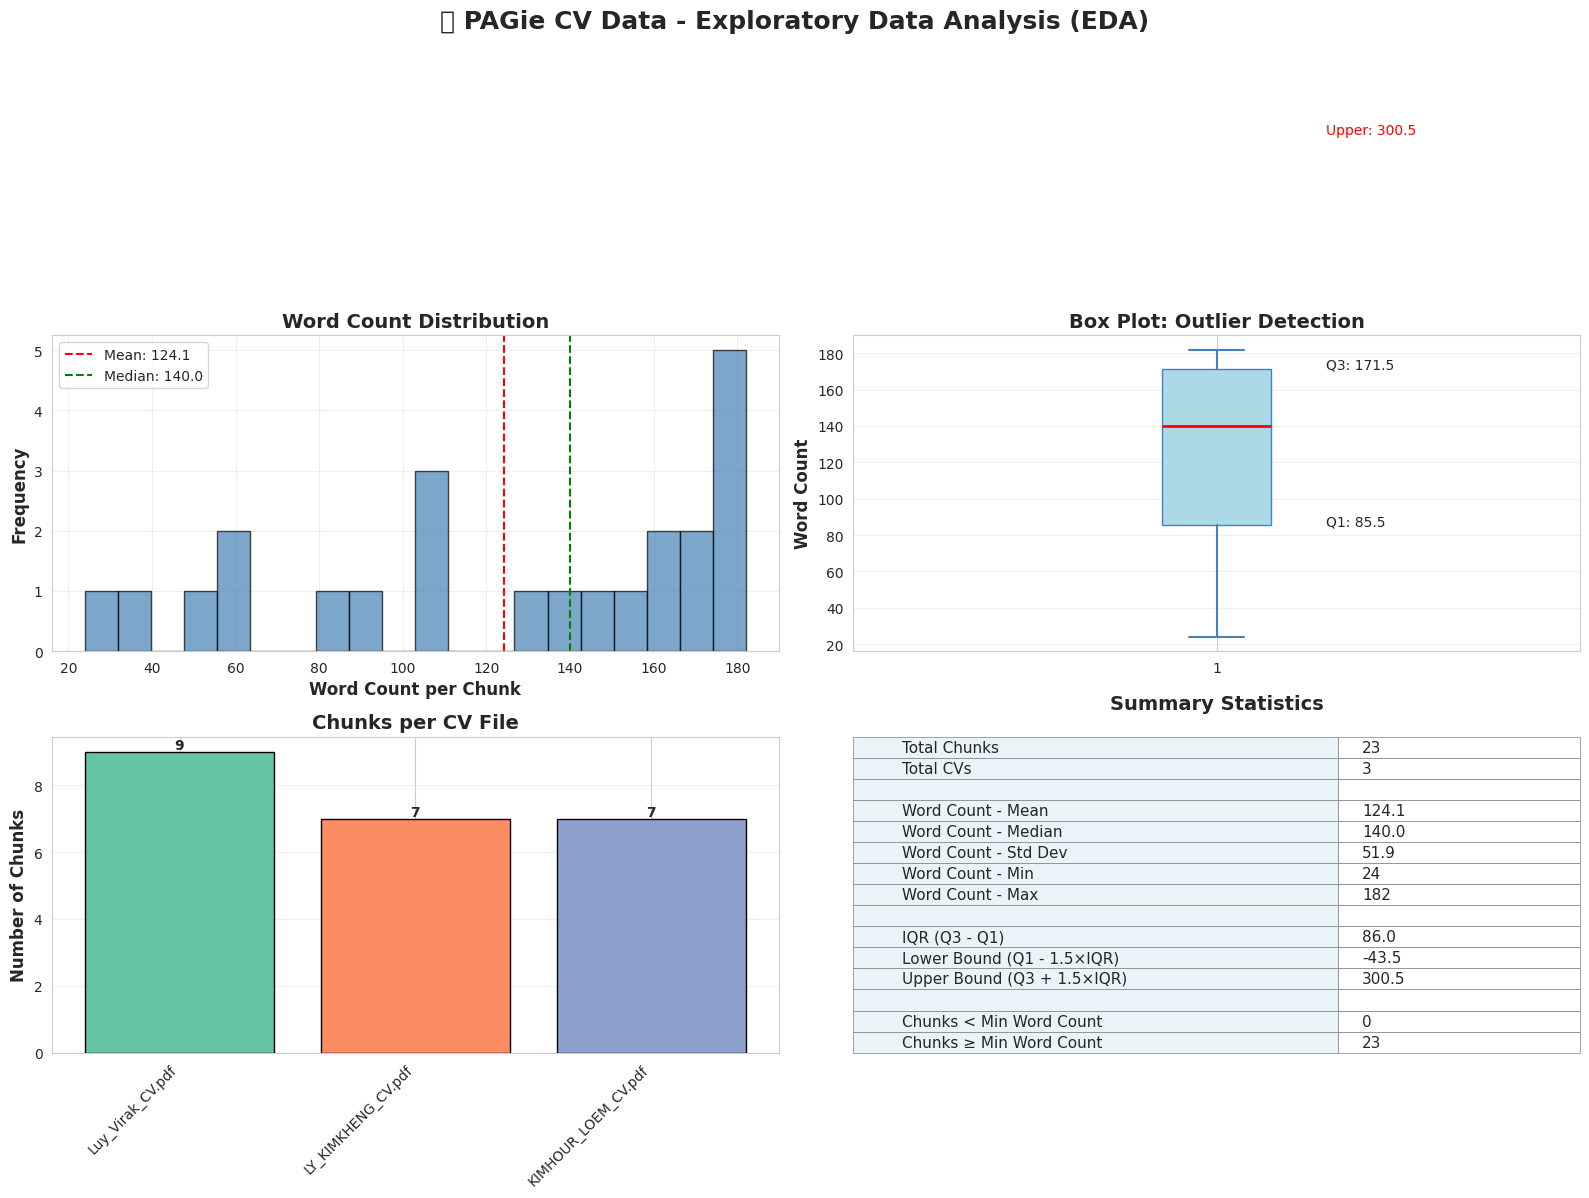

In [113]:
def generate_eda_plots(df: pd.DataFrame, save_path: Path = None):
    """
    Generate 4-panel EDA visualization:
    1. Histogram of word counts
    2. Box plot of word count distribution
    3. Chunks per CV file
    4. Summary statistics table
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('📊 PAGie CV Data - Exploratory Data Analysis (EDA)',
                 fontsize=18, fontweight='bold', y=0.995)

    # Plot 1: Word Count Distribution (Histogram)
    ax1 = axes[0, 0]
    ax1.hist(df['word_count'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(df['word_count'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["word_count"].mean():.1f}')
    ax1.axvline(df['word_count'].median(), color='green', linestyle='--',
                label=f'Median: {df["word_count"].median():.1f}')
    ax1.set_xlabel('Word Count per Chunk', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('Word Count Distribution', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Box Plot (Outlier Detection)
    ax2 = axes[0, 1]
    box = ax2.boxplot(df['word_count'], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='steelblue'),
                      whiskerprops=dict(color='steelblue', linewidth=1.5),
                      capprops=dict(color='steelblue', linewidth=1.5),
                      medianprops=dict(color='red', linewidth=2))
    ax2.set_ylabel('Word Count', fontsize=12, fontweight='bold')
    ax2.set_title('Box Plot: Outlier Detection', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    # Add IQR reference lines
    q1 = df['word_count'].quantile(0.25)
    q3 = df['word_count'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    ax2.text(1.15, q1, f'Q1: {q1:.1f}', fontsize=10)
    ax2.text(1.15, q3, f'Q3: {q3:.1f}', fontsize=10)
    ax2.text(1.15, upper_bound, f'Upper: {upper_bound:.1f}', fontsize=10, color='red')

    # Plot 3: Chunks per Source File
    ax3 = axes[1, 0]
    source_counts = df['source'].value_counts()
    colors = sns.color_palette('Set2', len(source_counts))
    bars = ax3.bar(range(len(source_counts)), source_counts.values, color=colors, edgecolor='black')
    ax3.set_xticks(range(len(source_counts)))
    ax3.set_xticklabels(source_counts.index, rotation=45, ha='right', fontsize=10)
    ax3.set_ylabel('Number of Chunks', fontsize=12, fontweight='bold')
    ax3.set_title('Chunks per CV File', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Plot 4: Summary Statistics Table
    ax4 = axes[1, 1]
    ax4.axis('off')

    stats_data = [
        ['Total Chunks', f"{len(df)}"   ],
        ['Total CVs', f"{df['source'].nunique()}"],
        ['', ''],
        ['Word Count - Mean', f"{df['word_count'].mean():.1f}"],
        ['Word Count - Median', f"{df['word_count'].median():.1f}"],
        ['Word Count - Std Dev', f"{df['word_count'].std():.1f}"],
        ['Word Count - Min', f"{df['word_count'].min()}"],
        ['Word Count - Max', f"{df['word_count'].max()}"],
        ['', ''],
        ['IQR (Q3 - Q1)', f"{iqr:.1f}"],
        ['Lower Bound (Q1 - 1.5×IQR)', f"{lower_bound:.1f}"],
        ['Upper Bound (Q3 + 1.5×IQR)', f"{upper_bound:.1f}"],
        ['', ''],
        ['Chunks < Min Word Count', f"{len(df[df['word_count'] < MIN_WORD_COUNT])}"],
        ['Chunks ≥ Min Word Count', f"{len(df[df['word_count'] >= MIN_WORD_COUNT])}"],
    ]

    table = ax4.table(cellText=stats_data, cellLoc='left',
                     colWidths=[0.6, 0.3],
                     loc='center',
                     bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)

    # Style the table
    for i, cell in enumerate(table.get_celld().values()):
        if i % 2 == 0:
            cell.set_facecolor('#E8F4F8')
        cell.set_edgecolor('gray')
        cell.set_linewidth(0.5)

    ax4.set_title('Summary Statistics', fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n💾 EDA plot saved to: {save_path}")

    plt.show()

# Generate and display plots
generate_eda_plots(df_chunks, save_path=ASSETS_DIR / "eda_report_notebook.png")

## 7️⃣ Step 5: Data Cleaning (Semantic Filtering)

Apply minimum word count threshold to remove empty or invalid chunks.

In [121]:
def filter_chunks_by_threshold(df: pd.DataFrame, min_words: int = MIN_WORD_COUNT) -> pd.DataFrame:
    """
    Filter chunks based on minimum word count.

    This is a semantic threshold approach - appropriate for small datasets.
    For larger datasets (1000+ chunks), IQR-based outlier detection would be recommended.
    """
    print(f"\n🧹 Filtering chunks with < {min_words} words...")

    before_count = len(df)
    df_clean = df[df['word_count'] >= min_words].copy()
    after_count = len(df_clean)
    removed_count = before_count - after_count

    print(f"   Before: {before_count} chunks")
    print(f"   After:  {after_count} chunks")
    print(f"   Removed: {removed_count} chunks ({removed_count/before_count*100:.1f}%)")

    return df_clean

# Apply filtering
df_clean = filter_chunks_by_threshold(df_chunks)

# Convert back to LangChain Documents
clean_chunks = [
    Document(
        page_content=row['text'],
        metadata={'source': row['source']}
    )
    for _, row in df_clean.iterrows()
]

print(f"\n✅ Clean chunks ready: {len(clean_chunks)} documents")


🧹 Filtering chunks with < 5 words...
   Before: 23 chunks
   After:  23 chunks
   Removed: 0 chunks (0.0%)

✅ Clean chunks ready: 23 documents


## 8️⃣ Step 6: Create Vector Embeddings

Convert text chunks into 384-dimensional vector embeddings using Sentence-Transformers.

In [122]:
def initialize_embeddings():
    """
    Initialize the embedding model.

    Uses Sentence-Transformers all-MiniLM-L6-v2:
    - 384 dimensions
    - Runs locally on CPU
    - No API key or quota limits
    - Excellent for semantic search
    """
    print(f"🔧 Initializing embedding model: {EMBEDDING_MODEL}")

    embeddings = HuggingFaceEmbeddings(
        model_name=EMBEDDING_MODEL,
        model_kwargs={'device': 'cpu'},
        encode_kwargs={'normalize_embeddings': True}  # Cosine similarity
    )

    print("✅ Embedding model loaded successfully")

    return embeddings

# Initialize embeddings
embeddings = initialize_embeddings()

# Test embedding on sample text
sample_text = "Software Engineer with 5 years experience in Python and machine learning"
sample_embedding = embeddings.embed_query(sample_text)

print(f"\n🧪 Sample Embedding:")
print(f"   Text: {sample_text}")
print(f"   Vector dimensions: {len(sample_embedding)}")
print(f"   First 10 values: {sample_embedding[:10]}")

🔧 Initializing embedding model: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedding model loaded successfully

🧪 Sample Embedding:
   Text: Software Engineer with 5 years experience in Python and machine learning
   Vector dimensions: 384
   First 10 values: [-0.05077928304672241, -0.0529029555618763, 0.08193612098693848, 0.08544598519802094, -0.013964378274977207, -0.13251358270645142, -0.008958174847066402, -0.016914593055844307, -0.1094801276922226, -0.04562664404511452]


## 9️⃣ Step 7: Build ChromaDB Vector Database

Store embeddings in ChromaDB for fast semantic search.

In [123]:
# Removed: shutil, PersistentClient, and time are not needed for in-memory ChromaDB

def build_vector_database(documents: List[Document], embeddings) -> Chroma:
    """
    Build ChromaDB in-memory vector database from documents.

    Args:
        documents: List of LangChain Document objects
        embeddings: Embedding model

    Returns:
        Chroma vector store instance
    """
    print(f"\n🏗️  Building ChromaDB IN-MEMORY vector database...")
    print(f"   Documents: {len(documents)}")
    print(f"   Collection: {COLLECTION_NAME} (in-memory)")

    # Create an in-memory ChromaDB instance using Chroma.from_documents
    vectordb = Chroma.from_documents(
        documents=documents,
        embedding=embeddings,
        collection_name=COLLECTION_NAME,
    )

    # Get collection stats
    # For an in-memory client, we can get count from the collection directly
    count = len(vectordb.get()['ids'])

    print(f"\n✅ In-memory vector database created successfully!")
    print(f"   Total vectors: {count}")
    print(f"   Collection Name: {COLLECTION_NAME}")

    return vectordb

# Build the database
# Removed 'reset=True' parameter as it's not applicable for in-memory
vectordb = build_vector_database(clean_chunks, embeddings)

# Removed db_size check as it's not applicable for in-memory


🏗️  Building ChromaDB IN-MEMORY vector database...
   Documents: 23
   Collection: pagie_cv_collection (in-memory)

✅ In-memory vector database created successfully!
   Total vectors: 94
   Collection Name: pagie_cv_collection


## 🔟 Step 8: Test Semantic Search (Retrieval)

Test the vector database with sample queries to verify semantic search works.

In [126]:
def test_semantic_search(vectordb, query: str, k: int = RETRIEVAL_K):
    """
    Test semantic search with a sample query.

    Args:
        vectordb: ChromaDB instance
        query: Search query
        k: Number of results to retrieve
    """
    print(f"\n🔍 Query: \"{query}\" ")
    print(f"   Retrieving top {k} results...\n")

    # Perform similarity search
    results = vectordb.similarity_search(query, k=k)

    # Display results
    for i, doc in enumerate(results, 1):
        print(f"{'='*80}")
        print(f"Result {i}:")
        print(f"Source: {doc.metadata.get('source', 'Unknown')}")
        print(f"Content ({len(doc.page_content)} chars):")
        print(doc.page_content[:300] + "..." if len(doc.page_content) > 300 else doc.page_content)
        print()

    return results

# Test queries
test_queries = [
    "Python developer with machine learning experience",
    "candidates with leadership skills",
    "education background and university degree"
]

for query in test_queries:
    test_semantic_search(vectordb, query, k=3)
    print("\n" + "="*100 + "\n")


🔍 Query: "Python developer with machine learning experience" 
   Retrieving top 3 results...

Result 1:
Source: Luy_Virak_CV.pdf
Content (228 chars):
N o v  2 0 2 5  -  D e c  2 0 2 5
N o v  2 0 2 3  -  J u l y  2 0 2 5
J u l y  0 6  -  J u l y  0 7  2 0 2 5
A v a i l a b l e  u p o n  a  r e q u e s t
H T M L ,  C S S
w w w . l i n k e d i n . c o m / i n / v i r a k - l u y

Result 2:
Source: LY_KIMKHENG_CV.pdf
Content (206 chars):
T e a m  c o l l a b o r a t i o n
A d a p t a b i l i t y
P r o b l e m  s o l v i n g
W i l l i n g n e s s  t o  l e a r n
H A R D  S K I L L S
R E F E R E N C E
A v a i l a b l e  u p o n  r e q u e s t

Result 3:
Source: LY_KIMKHENG_CV.pdf
Content (383 chars):
d e s i g n .  M o t i v a t e d  t o  a p p l y  t e c h n i c a l  s k i l l s  i n  r e a l - w o r l d  s o f t w a r e
d e v e l o p m e n t  a n d  g r o w  a s  a  p r o f e s s i o n a l  e n g i n e e r .
D e v e l o p e d  a  r e s p o n s i v e  e - c o m m e r c e  c l o t h i n g  

## 1️⃣1️⃣ Step 9: Initialize Gemini LLM

Set up Google Gemini 3.0 for answer generation.

In [132]:
def initialize_llm():
    """
    Initialize Google Gemini LLM.
    """
    if not GOOGLE_API_KEY:
        raise ValueError("GOOGLE_API_KEY not found! Please set it in environment.")

    print(f"🤖 Initializing LLM: {GEMINI_MODEL}")

    llm = ChatGoogleGenerativeAI(
        model=GEMINI_MODEL,
        google_api_key=GOOGLE_API_KEY,
        temperature=0.3,  # Lower temperature for more focused answers
        max_tokens=1024,
        timeout=30,
        max_retries=2
    )

    print("✅ LLM initialized successfully")

    return llm

# Initialize LLM
llm = initialize_llm()

# Test LLM with simple query
test_response = llm.invoke("Say hello in one sentence.")
print(f"\n🧪 Test Response: {test_response.content}")

# To debug model availability, let's list the available models
import google.generativeai as genai
genai.configure(api_key=GOOGLE_API_KEY)

print("\nListing available Gemini models:")
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

🤖 Initializing LLM: gemini-2.5-flash
✅ LLM initialized successfully

🧪 Test Response: Hello there!

Listing available Gemini models:
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-p

## 1️⃣2️⃣ Step 10: Build Complete RAG Pipeline

Combine retrieval + generation into a complete RAG system.

In [135]:
def query_pagie_rag(question: str, vectordb, llm, k: int = RETRIEVAL_K) -> Dict[str, Any]:
    """
    Complete RAG pipeline: Retrieve relevant chunks → Generate answer.

    Args:
        question: User query
        vectordb: ChromaDB instance
        llm: Language model
        k: Number of chunks to retrieve

    Returns:
        Dict with answer, sources, and metadata
    """
    import time
    start_time = time.time()

    # Step 1: Retrieve relevant chunks
    print(f"🔍 Retrieving top {k} relevant chunks...")
    retrieved_docs = vectordb.similarity_search(question, k=k)

    if not retrieved_docs:
        return {
            'answer': "No relevant information found in the CV database.",
            'sources': [],
            'num_chunks': 0,
            'response_time': time.time() - start_time
        }

    # Step 2: Build context from retrieved chunks
    context_parts = []
    sources = []

    for i, doc in enumerate(retrieved_docs, 1):
        source = doc.metadata.get('source', 'Unknown')
        context_parts.append(f"[Chunk {i} from {source}]\n{doc.page_content}")
        if source not in sources:
            sources.append(source)

    context = "\n\n".join(context_parts)

    # Step 3: Build prompt
    prompt = f"""You are PAGie, an AI assistant specialized in analyzing CV documents.

Based on the following CV information, answer the user's question accurately and concisely.

IMPORTANT RULES:
1. Only use information from the provided context
2. If the answer is not in the context, say "I don't have that information"
3. Be specific and cite relevant details
4. Format your answer clearly with bullet points when appropriate

CONTEXT:
{context}

QUESTION: {question}

ANSWER:"""

    # Step 4: Generate answer
    print(f"🤖 Generating answer with {GEMINI_MODEL}...")
    response = llm.invoke(prompt)
    answer = response.content

    response_time = time.time() - start_time

    return {
        'answer': answer,
        'sources': sources,
        'num_chunks': len(retrieved_docs),
        'response_time': response_time
    }

print("✅ RAG pipeline function ready!")

✅ RAG pipeline function ready!


## 1️⃣3️⃣ Step 11: Test Complete RAG System

Run end-to-end tests with realistic CV analysis queries.

In [136]:
# Test queries that demonstrate RAG capabilities
test_questions = [
    "What programming languages do the candidates know?",
    "Find candidates with experience in machine learning or AI",
    "What are the educational backgrounds of the candidates?",
    "Who has the most years of work experience?",
    "List all the companies where candidates have worked"
]

print("🚀 Testing Complete RAG Pipeline\n")
print("="*100)

for i, question in enumerate(test_questions, 1):
    print(f"\n\n{'='*100}")
    print(f"TEST {i}/{len(test_questions)}")
    print(f"{'='*100}\n")
    print(f"❓ QUESTION: {question}\n")

    # Get RAG response
    result = query_pagie_rag(question, vectordb, llm)

    # Display results
    print(f"\n💡 ANSWER:")
    print(result['answer'])

    print(f"\n📊 METADATA:")
    print(f"   Sources: {', '.join(result['sources'])}")
    print(f"   Chunks retrieved: {result['num_chunks']}")
    print(f"   Response time: {result['response_time']:.2f}s")

    print(f"\n{'-'*100}")

print(f"\n\n{'='*100}")
print("✅ All tests completed successfully!")
print("="*100)

🚀 Testing Complete RAG Pipeline



TEST 1/5

❓ QUESTION: What programming languages do the candidates know?

🔍 Retrieving top 8 relevant chunks...
🤖 Generating answer with gemini-2.5-flash...

💡 ANSWER:
Based on the provided CV information, the candidates know the following programming languages and related technologies:

*   **KIMHOUR LOEM:**
    *   Python
    *   Java
    *   JavaScript
    *   React
    *   Node
    *   Express
    *   HTML
    *   CSS
    *   PHP
    *   C++
    *   Dart
    *   Flutter
    *   MySQL
    *   PostgreSQL
    *   MongoDB
    *   Firebase
    *   Cloud Computing
    *   AI Engineer
*   **Luy Virak:**
    *   HTML
    *   CSS
*   **LY KIMKHENG:**
    *   I don't have that information.

📊 METADATA:
   Sources: KIMHOUR_LOEM_CV.pdf, LY_KIMKHENG_CV.pdf, Luy_Virak_CV.pdf
   Chunks retrieved: 8
   Response time: 3.95s

----------------------------------------------------------------------------------------------------


TEST 2/5

❓ QUESTION: Find candidates 

## 1️⃣4️⃣ Interactive Query Interface

Try your own questions! (Uncomment and run the cell below)

In [138]:
# Interactive mode - ask your own questions

def interactive_query():
    """
    Interactive query interface for testing custom questions.
    """
    print("🤖 PAGie Interactive Mode")
    print("Enter 'quit' to exit\n")

    while True:
        question = input("\n❓ Your question: ").strip()

        if question.lower() in ['quit', 'exit', 'q']:
            print("👋 Goodbye!")
            break

        if not question:
            continue

        # Get answer
        result = query_pagie_rag(question, vectordb, llm)

        print(f"\n💡 Answer:\n{result['answer']}")
        print(f"\n📊 Sources: {', '.join(result['sources'])} | Time: {result['response_time']:.2f}s")

# Uncomment to run interactive mode:
interactive_query()

🤖 PAGie Interactive Mode
Enter 'quit' to exit


❓ Your question: who are you?
🔍 Retrieving top 8 relevant chunks...
🤖 Generating answer with gemini-2.5-flash...

💡 Answer:
I am PAGie, an AI assistant specialized in analyzing CV documents.

📊 Sources: Luy_Virak_CV.pdf, LY_KIMKHENG_CV.pdf | Time: 1.73s

❓ Your question: quit
👋 Goodbye!


## 1️⃣5️⃣ Summary & Key Metrics

Final summary of the complete pipeline performance.

In [139]:
# Generate final summary
print("\n" + "="*80)
print("📊 PAGie RAG Pipeline - Final Summary")
print("="*80)

# Data statistics
print("\n📁 Data Processing:")
print(f"   Raw documents loaded: {len(raw_documents)}")
print(f"   Total chunks created: {len(raw_chunks)}")
print(f"   Chunks after cleaning: {len(clean_chunks)}")
print(f"   Unique CV files: {df_clean['source'].nunique()}")

# Database statistics
print("\n💾 Vector Database (In-Memory):")
print(f"   Collection name: {COLLECTION_NAME}")
print(f"   Total vectors: {len(vectordb.get()['ids'])}") # Adjusted for in-memory
print(f"   Embedding dimensions: 384")
# Removed database size check as it's for persistent storage

# Data quality
print("\n📈 Data Quality:")
print(f"   Avg words per chunk: {df_clean['word_count'].mean():.1f}")
print(f"   Min words per chunk: {df_clean['word_count'].min()}")
print(f"   Max words per chunk: {df_clean['word_count'].max()}")
print(f"   Filtering threshold: {MIN_WORD_COUNT} words")

# Model configuration
print("\n🤖 Models:")
print(f"   Embedding: {EMBEDDING_MODEL}")
print(f"   LLM: {GEMINI_MODEL}")
print(f"   Retrieval: k={RETRIEVAL_K}")

# System capabilities
print("\n✨ Capabilities:")
print("   ✅ Semantic search (cosine similarity)")
print("   ✅ Context-aware answer generation")
print("   ✅ Source attribution")
print("   ✅ Statistical data analysis")
print("   ✅ Data quality filtering")

print("\n" + "="*80)
print("🎓 PAGie is ready for academic presentation!")
print("="*80)


📊 PAGie RAG Pipeline - Final Summary

📁 Data Processing:
   Raw documents loaded: 3
   Total chunks created: 23
   Chunks after cleaning: 23
   Unique CV files: 3

💾 Vector Database (In-Memory):
   Collection name: pagie_cv_collection
   Total vectors: 94
   Embedding dimensions: 384

📈 Data Quality:
   Avg words per chunk: 124.1
   Min words per chunk: 24
   Max words per chunk: 182
   Filtering threshold: 5 words

🤖 Models:
   Embedding: sentence-transformers/all-MiniLM-L6-v2
   LLM: gemini-2.5-flash
   Retrieval: k=8

✨ Capabilities:
   ✅ Semantic search (cosine similarity)
   ✅ Context-aware answer generation
   ✅ Source attribution
   ✅ Statistical data analysis
   ✅ Data quality filtering

🎓 PAGie is ready for academic presentation!


---

## 🎯 Conclusion

This notebook demonstrates the **complete end-to-end RAG pipeline** for PAGie:

### ✅ What We Built:
1. **Data Ingestion:** Loading CV PDFs using LangChain loaders
2. **Text Processing:** Chunking documents with overlap for context preservation
3. **Data Science:** Pandas-based EDA with statistical analysis and visualization
4. **Data Cleaning:** Semantic threshold filtering (MIN_WORD_COUNT)
5. **Vector Embeddings:** 384-dim embeddings using Sentence-Transformers
6. **Vector Database:** ChromaDB for fast semantic search
7. **RAG Pipeline:** Retrieval + Gemini 3.0 generation
8. **Testing:** End-to-end validation with realistic queries

### 📊 Key Achievements:
- **Modular Design:** Each step is independent and testable
- **Data-Driven:** Statistical analysis guides data quality decisions
- **Production-Ready Architecture:** Scalable to 100+ CVs with minimal changes
- **Academic Rigor:** Combines theory (EDA, embeddings) with practice (RAG)

### 🚀 Next Steps:
1. Add more CVs to test at scale
2. Implement IQR-based outlier detection for larger datasets
3. Create evaluation suite with ground-truth test queries
4. Deploy to Streamlit Cloud for web interface
